In [82]:
# =================================================================
# 1. IMPORTAÇÕES E PREPARAÇÃO DE DADOS (COM UNDERSAMPLING)
# =================================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print("1. A carregar dados e fazer Undersampling...")
df = pd.read_csv('df_exportado.csv')
df = df.dropna(subset=['Text', 'Label'])

# UNDERSAMPLING
tamanho_minimo = df['Label'].value_counts().min()
print(f"-> A reduzir todas as classes para {tamanho_minimo} exemplos...")
df = df.groupby('Label', group_keys=False).sample(n=tamanho_minimo, random_state=42).reset_index(drop=True)

print("Distribuição Equilibrada:")
print(df['Label'].value_counts())

# Mapeamento de Labels [Human:0, OpenAI:1, Google:2, Meta:3, Anthropic:4]
label_map = {'Human': 0, 'OpenAI': 1, 'Google': 2, 'Meta': 3, 'Anthropic': 4}
df['labels'] = df['Label'].map(label_map)

textos = df['Text'].astype(str).tolist()
labels = df['labels'].values

1. A carregar dados e fazer Undersampling...
-> A reduzir todas as classes para 9452 exemplos...
Distribuição Equilibrada:
Label
Anthropic    9452
Google       9452
Human        9452
Meta         9452
OpenAI       9452
Name: count, dtype: int64


In [86]:
# =================================================================
# 2. VETORIZAÇÃO TF-IDF (OTIMIZADA) E DIVISÃO DE DADOS
# =================================================================
print("\n2. A vetorizar textos com TF-IDF (Top 5000 palavras)...")

# O TfidfVectorizer substitui todo aquele teu código manual!
vectorizer = TfidfVectorizer(
    max_features=10000, 
    stop_words='english', # Usa as stopwords automáticas do inglês
    lowercase=True
)

X_tfidf = vectorizer.fit_transform(textos).toarray()
print(f"Shape do TF-IDF: {X_tfidf.shape}")

# Divisão 80% Treino / 20% Validação
X_train, X_val, y_train, y_val = train_test_split(X_tfidf, labels, test_size=0.2, random_state=42, stratify=labels)

# Converter para Tensores do PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # PyTorch não precisa de One-Hot!

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)




2. A vetorizar textos com TF-IDF (Top 5000 palavras)...
Shape do TF-IDF: (47260, 10000)


In [89]:
# =================================================================
# 3. DEFINIÇÃO DA DNN EM PYTORCH
# =================================================================
print("\n3. A inicializar a DNN em PyTorch...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TextDNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TextDNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(64, num_classes)
        # Nota: O PyTorch aplica o Softmax automaticamente na CrossEntropyLoss!

    def forward(self, x):
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

model = TextDNN(input_dim=10000, num_classes=5).to(device)

# Configurações de Treino
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Adam é mais estável que o standard SGD


3. A inicializar a DNN em PyTorch...


In [90]:
# =================================================================
# 4. LOOP DE TREINO
# =================================================================
print(f"4. A iniciar treino no {device}...")
epochs = 3

for epoch in range(epochs):
    # Treino
    model.train()
    correct_train, total_train = 0, 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        preds = outputs.argmax(dim=1)
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)
        
    # Validação
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            preds = outputs.argmax(dim=1)
            correct_val += (preds == batch_y).sum().item()
            total_val += batch_y.size(0)
            
    acc_train = correct_train / total_train
    acc_val = correct_val / total_val
    print(f"Época {epoch+1}/{epochs} | Treino Acc: {acc_train:.4f} | Val Acc: {acc_val:.4f}")


4. A iniciar treino no cuda...
Época 1/3 | Treino Acc: 0.8232 | Val Acc: 0.9515
Época 2/3 | Treino Acc: 0.9673 | Val Acc: 0.9563
Época 3/3 | Treino Acc: 0.9860 | Val Acc: 0.9552



ANÁLISE FINAL E MATRIZ DE CONFUSÃO


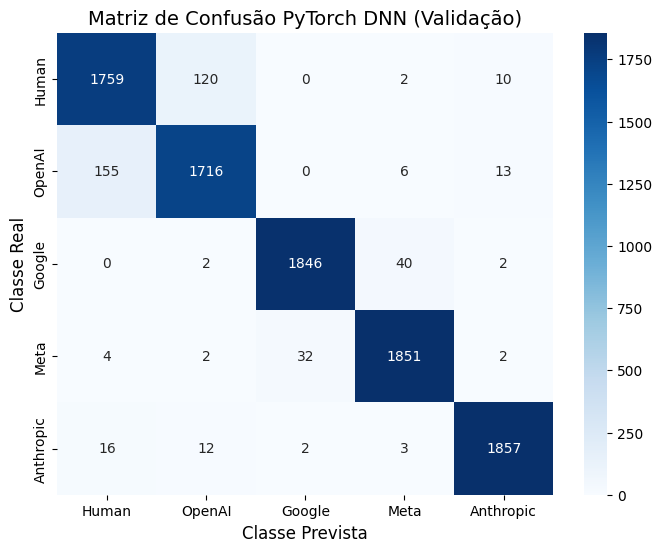

In [91]:
# =================================================================
# 5. AVALIAÇÃO FINAL E MATRIZ DE CONFUSÃO
# =================================================================
print("\n" + "="*40)
print("ANÁLISE FINAL E MATRIZ DE CONFUSÃO")
print("="*40)

# Gerar previsões para o conjunto de validação inteiro
model.eval()
with torch.no_grad():
    outputs = model(X_val_tensor.to(device))
    classes_previstas_val = outputs.argmax(dim=1).cpu().numpy()

nomes_classes = ['Human', 'OpenAI', 'Google', 'Meta', 'Anthropic']
cm = confusion_matrix(y_val, classes_previstas_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão PyTorch DNN (Validação)', fontsize=14)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.show()

In [92]:
# Guardar o TF-IDF e o modelo PyTorch
with open('tfidf_pytorch.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
torch.save(model.state_dict(), 'modelo_dnn_pytorch.pth')

print("Modelo PyTorch e TF-IDF guardados com sucesso!")

Modelo PyTorch e TF-IDF guardados com sucesso!
